Équation de la droite : y = 80.24 + 1.60 * x
Intercept (theta_0): 80.24
Coefficient (theta_1): 1.60
Prix prédit pour une maison de 130 m² : 287.62 k€


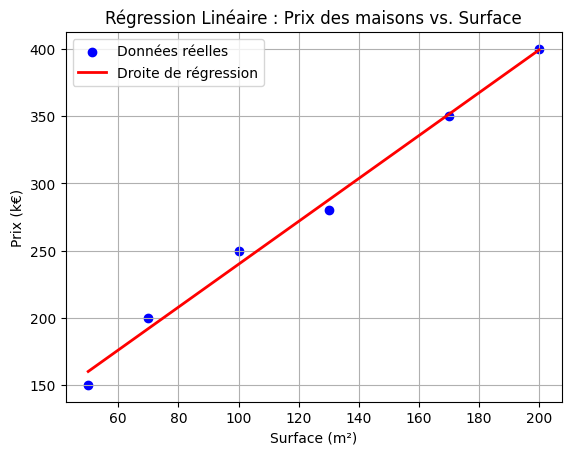

In [1]:
# Implémentation de la Régression Linéaire en Python

import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# 1. Génération de données synthétiques
# X représente la surface des maisons (en m²)
X = np.array([50, 70, 100, 130, 170, 200]).reshape(-1, 1)
# y représente le prix des maisons (en milliers d'euros)
y = np.array([150, 200, 250, 280, 350, 400])

# 2. Création et entraînement du modèle
# On instancie le modèle de régression linéaire
model = LinearRegression()

# On entraîne le modèle sur nos données (X, y)
# La méthode.fit() exécute les calculs vus précédemment pour trouver les meilleurs coefficients.
model.fit(X, y)

# 3. Extraction des coefficients et de l'intercept
# L'intercept (theta_0 ou 'a') est stocké dans l'attribut.intercept_
intercept = model.intercept_
# Le coefficient (theta_1 ou 'b') est stocké dans l'attribut.coef_
coefficient = model.coef_[0]

print(f"Équation de la droite : y = {intercept:.2f} + {coefficient:.2f} * x")
print(f"Intercept (theta_0): {model.intercept_:.2f}")
print(f"Coefficient (theta_1): {model.coef_[0]:.2f}")

# 4. Faire des prédictions
# Prédire le prix pour une nouvelle maison de 130 m²
nouvelle_surface = np.array([[130]])
prix_predit = model.predict(nouvelle_surface)[0]
print(f"Prix prédit pour une maison de 130 m² : {prix_predit:.2f} k€")

# 5. Visualisation des résultats
plt.scatter(X, y, color='blue', label='Données réelles')
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Droite de régression')
plt.title('Régression Linéaire : Prix des maisons vs. Surface')
plt.xlabel('Surface (m²)')
plt.ylabel('Prix (k€)')
plt.legend()
plt.grid(True)
plt.show()

Précision du modèle : 0.93


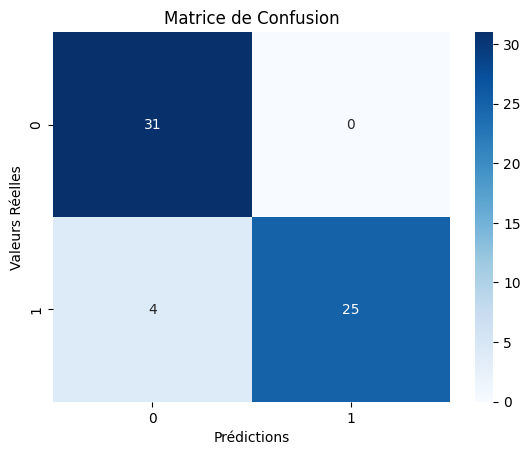

In [2]:
# Implémentation de la Régression Logistique en Python

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Génération de données synthétiques pour la classification
# Feature 1: taille de la tumeur, Feature 2: âge du patient
np.random.seed(0)
# Données pour la classe 0 (bénigne)
X0 = np.random.normal(loc=[2, 50], scale=[0.5, 10], size=(100, 2))
y0 = np.zeros(100)
# Données pour la classe 1 (maligne)
X1 = np.random.normal(loc=[5, 60], scale=[1.5, 12], size=(100, 2))
y1 = np.ones(100)

X = np.vstack((X0, X1))
y = np.hstack((y0, y1))

# 2. Séparation des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Création et entraînement du modèle
# 'solver' est l'algorithme d'optimisation utilisé. 'liblinear' est bon pour les petits jeux de données.
# 'penalty' spécifie la régularisation pour éviter le sur-apprentissage.
model = LogisticRegression(solver='liblinear', random_state=42)

# Entraînement du modèle
model.fit(X_train, y_train)

# 4. Prédictions et Évaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Précision du modèle : {accuracy:.2f}")

# Affichage de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de Confusion')
plt.xlabel('Prédictions')
plt.ylabel('Valeurs Réelles')
plt.show()

# Pour la classification multi-classes, scikit-learn gère cela automatiquement
# via la stratégie 'One-vs-Rest' (OvR) par défaut.
# On peut aussi spécifier 'multinomial' pour certains solveurs comme 'lbfgs'.
# model_multi = LogisticRegression(multi_class='multinomial', solver='lbfgs')

Précision du SVM linéaire : 0.88
Précision du SVM avec noyau RBF : 0.98


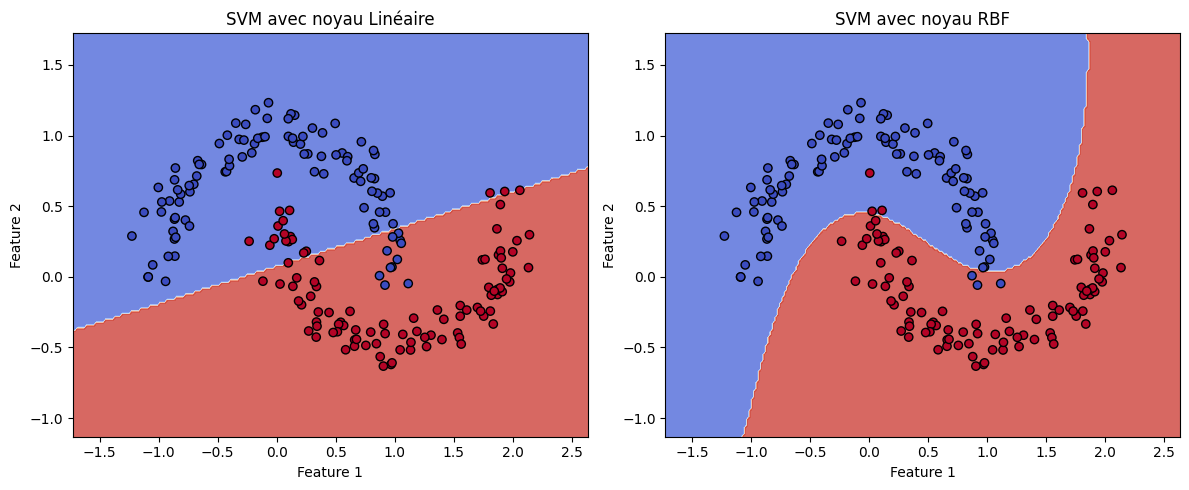

In [3]:
# Implémentation des SVM en Python

import numpy as np
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 1. Génération de données non-linéairement séparables
X, y = make_moons(n_samples=200, noise=0.1, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Création et entraînement d'un SVM avec noyau linéaire
# Ce modèle devrait avoir du mal avec ces données.
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)
print(f"Précision du SVM linéaire : {accuracy_score(y_test, y_pred_linear):.2f}")

# 3. Création et entraînement d'un SVM avec noyau RBF (Gaussien)
# 'C' est le paramètre de régularisation : un C faible crée une marge plus grande mais tolère des erreurs.
# 'gamma' définit l'influence d'un seul exemple d'entraînement.
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='auto')
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)
print(f"Précision du SVM avec noyau RBF : {accuracy_score(y_test, y_pred_rbf):.2f}")

# 4. Fonction pour visualiser la frontière de décision
def plot_decision_boundary(model, X, y, title):
    h = .02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

# Visualisation
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_decision_boundary(svm_linear, X, y, 'SVM avec noyau Linéaire')
plt.subplot(1, 2, 2)
plot_decision_boundary(svm_rbf, X, y, 'SVM avec noyau RBF')
plt.tight_layout()
plt.show()